<a href="https://colab.research.google.com/github/bernardozschaber/bernardozschaber.github.io/blob/main/Flautim_API_em_Modo_Offline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Execução do Flautim API em Modo Offline

Este notebook foi criado com o objetivo de **demonstrar como executar o Flautim API em modo offline e escrita de logs e outputs em um arquivo HDF5:**, utilizando os tutoriais oficiais disponíveis no repositório:

- 🔗 Flautim API: https://github.com/FutureLab-DCC/flautim2  
- 🔗 Tutoriais: https://github.com/FutureLab-DCC/flautim_tutoriais  

## 🎯 Objetivo

O foco deste notebook é:
- Apresentar um **passo a passo prático** para execução local (offline) do Flautim;
- Ilustrar como configurar o ambiente;
- Executar experimentos a partir dos tutoriais;
- Registrar resultados, outputs e logs sem depender da plataforma online.

Este material é especialmente útil para:
- Testes locais;
- Depuração;
- Execução em ambientes restritos (sem acesso externo);
- Compreensão do fluxo interno de execução do Flautim API.

## 📌 Observações Importantes

- Este notebook **não substitui** a documentação oficial dos repositórios, mas serve como material complementar e didático.
- Alguns exemplos aqui apresentados são baseados diretamente nos tutoriais do projeto.
- O comportamento pode variar conforme o sistema operacional, versão do Python e bibliotecas instaladas.
- Recomenda-se executar as células **na ordem apresentada** um por um.
- Devido a algumas limitações do Google Colab quanto ao uso do Miniconda e à utilização de versões mais antigas do Python, pode ser necessário, em determinados casos, refazer todo o procedimento de configuração do ambiente após a execução de um experimento. Dessa forma, recomenda-se que o presente ambiente seja utilizado apenas para fins didáticos. Para testes e uso efetivo da Flautim API Offline, orienta-se a utilização de um ambiente configurado localmente no computador do usuário.

-----

#**1. Setup**
Nesta seção são realizadas todas as configurações iniciais necessárias para a execução dos experimentos.

Aqui são definidos e importados os principais pacotes utilizados, bem como ajustados parâmetros globais do ambiente, como caminhos de arquivos, variáveis de configuração e opções de execução.

O objetivo deste bloco é garantir que o ambiente esteja corretamente preparado antes da execução do experimento propriamente dito, evitando inconsistências relacionadas a dependências, caminhos inválidos ou parâmetros ausentes.

Esta etapa também centraliza as definições de configuração, facilitando a reprodutibilidade dos experimentos e a manutenção do código.

In [ ]:
# ------------------------------------------------------------
# Instala o Miniconda no Colab e registra um kernel Python 3.12.9
# para execução do notebook (uso experimental).
# A instalação é temporária e será perdida ao reiniciar o runtime.
# ------------------------------------------------------------

!wget -O mini.sh https://repo.anaconda.com/miniconda/Miniconda3-py312_25.3.1-1-Linux-x86_64.sh
#!wget -O mini.sh https://repo.anaconda.com/miniconda/Miniconda3-py312_25.1.1-0-Linux-aarch64.sh
!chmod +x mini.sh
!bash ./mini.sh -b -f -p /usr/local
!conda install -q -y jupyter
!conda install -q -y google-colab -c conda-forge
!python -m ipykernel install --name "py3129" --user

--2026-03-24 20:17:30--  https://repo.anaconda.com/miniconda/Miniconda3-py312_25.3.1-1-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:bf9e, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 154162194 (147M) [application/octet-stream]
Saving to: ‘mini.sh’

mini.sh             100%[===================>] 147.02M  45.2MB/s    in 3.4s    

2026-03-24 20:17:33 (43.8 MB/s) - ‘mini.sh’ saved [154162194/154162194]

PREFIX=/usr/local
Unpacking payload ...
entry_point.py:256: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
entry_point.py:256: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.

I

In [ ]:
! python3 --version

Python 3.12.9


In [ ]:
# ------------------------------------------------------------
# Instala as principais bibliotecas para o Flautim funcionar (Flower, Torch,
# Ray, MongoDB, Pandas, NumPy, HDF5, etc.) no ambiente do Colab.
#
# Obs. Não reinicie o kernel durante todo o procedimento,
#       existe uma celula a seguir para isso
# ------------------------------------------------------------
!pip install -U "flwr[simulation]"
!pip install flwr==1.13.1
!pip install torch==2.6.0
!pip install pymongo==4.10.1
!pip install schedule==1.2.2
!pip install psutil==6.1.0
!pip install pandas==2.2.2
!pip install yarl==1.17.1
!pip install torchvision==0.20.0
!pip install torchmetrics==1.6.0
!pip install numpy==1.26.4
!pip install pyyaml
!pip install h5py
!pip install datasets
!pip install flwr_datasets
!pip install pathvalidate


#Instalando o Ray de forma a funcionar no Colab
!pip install ray==2.40.0 --target=/usr/local/lib/python3.12/dist-packages

!pip install git+https://github.com/FutureLab-DCC/flautim2.git@flautim2_offline

print("\n\nBibliotecas instaladas...")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 613.9/613.9 kB 28.7 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1
  Attempting uninstall: cryptography
    Found existing installation: cryptography 44.0.1
    Uninstalling cryptography-44.0.1:
      Successfully uninstalled cryptography-44.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour i

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.6
    Uninstalling protobuf-6.33.6:
      Successfully uninstalled protobuf-6.33.6
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.78.0
    Uninstalling grpcio-1.78.0:
      Successfully uninstalled grpcio-1.78.0
  Attempting uninstall: cryptography
    Found existing installation: cryptography 46.0.5
    Uninstalling cryptography-46.0.5:
      Successfully uninstalled cryptography-46.0.5
  Attempting uninstall: typer
    Found existing installation: typer 0.20.1
    Uninstalling typer-0.20.1:
      Successfully uninstalled typer-0.20.1
  Attempting uninstall: flwr
    Found existing installation: flwr 1.27.0
    Uninstalling flwr-1.27.0:
      Successfully uninstalled flwr-1.27.0
ERROR: pip's dependency resolver does not currently

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 96.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3
  Attempting uninstall: yarl
    Found existing installation: yarl 1.23.0
    Uninstalling yarl-1.23.0:
      Successfully uninstalled yarl-1.23.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.6/209.6 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 144.8 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.2.0
    Uninstalling triton-3.2.0:
      Successfully uninstalled triton-3.2.0
  Attempting uninstall: torch
    Found existing installation: torch 2.6.0
    Uninstalling torch-2.6.0:
      Successfully uninstalled torch-2.6.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 156.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 149.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.8 MB/s eta 0:00:00


  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached msgpack-1.1.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 61.9 MB/s eta 0:00:00
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached msgpack-1.1.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (427 kB)
Using cached filelock-3.25.2-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 49.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-health-checking 1.78.0 requires grpcio>=1.78.0, but you have grpcio 1.64.3 which is incompatible.
grpcio-health-checking 1.78.0 requires protobuf<7.0.0,>=6.31.1, but you have proto

  Cloning https://github.com/FutureLab-DCC/flautim2.git (to revision flautim2_offline) to /tmp/pip-req-build-7200bboo
  Running command git clone --filter=blob:none --quiet https://github.com/FutureLab-DCC/flautim2.git /tmp/pip-req-build-7200bboo
  Running command git checkout -b flautim2_offline --track origin/flautim2_offline
  Switched to a new branch 'flautim2_offline'
  Branch 'flautim2_offline' set up to track remote branch 'flautim2_offline' from 'origin'.
  Resolved https://github.com/FutureLab-DCC/flautim2.git to commit ef4b75c7598bde9ceb72b05d83bd1d577f81186f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for flautim_api: filename=flautim_api-0.0.2-py3-none-any.whl size=26576 sha256=b993f394fc518b472c677997257fa212cc5f43a26e68c1adac08486c4746a22e
  Stored in directory: /tmp/pip-ephem-wheel-cache-4j3n0j_u/wheels/ea/45/41/cda9f897e16d156fd3960c30cc9f08f3cd3925ceb07630be62
Suc

In [ ]:
# ------------------------------------------------------------
# Reinicia o kernel do notebook para aplicar alterações no ambiente
# e verifica a versão do Python após o reinício.
# ------------------------------------------------------------
import IPython
IPython.Application.instance().kernel.do_shutdown(True)
! python3 --version
! python3 -m pip list | grep flautim


Python 3.12.9
flautim_api               0.0.2


In [ ]:
# ------------------------------------------------------------
# Ajusta manualmente o sys.path para incluir diretórios do
# Python 3.12 e o repositório local flautim2, permitindo a
# importação dos módulos do projeto no Colab.
# ------------------------------------------------------------
import sys
sys.path.append('/usr/local/lib/python3.12/site-packages/')
sys.path.append('/usr/local/lib/python3.12/dist-packages/')
sys.path.append('/usr/local/')
sys.path.append('/usr/lib/python3.12/')
sys.path.append('/usr/local/lib/python3.12/')
#sys.path.append('/content/flautim2')
print (sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/usr/local/lib/python3.12/site-packages/', '/usr/local/lib/python3.12/dist-packages/', '/usr/local/', '/usr/lib/python3.12/', '/usr/local/lib/python3.12/']


In [ ]:
# ------------------------------------------------------------
# baixa o pacote flautim2 (se ainda não existir) e
# faz o download do arquivo iris.csv para uso no experimento.
# ------------------------------------------------------------
import os

# Instala gdown se não estiver disponível
!pip install -q gdown

# IDs dos arquivos no Google Drive
view_h5_id = "1Dnemdkj82jZ-VbO4iI85ZGSnebYTI1sg" # view_h5.py

view_h5_filename = "view_h5.py"

# Download view_h5.py
if not os.path.exists(view_h5_filename):
    !gdown --id {view_h5_id} -O {view_h5_filename}
    print(f"{view_h5_filename} downloaded.")
else:
    print(f"{view_h5_filename} already exists.")

# Download iris.csv
csv_url = "https://raw.githubusercontent.com/FutureLab-DCC/flautim_tutoriais/refs/heads/main/TUTORIAL_1/iris.csv"
csv_filename = "iris.csv"
if not os.path.exists(csv_filename):
  !wget -O {csv_filename} {csv_url}
  print(f'{csv_filename} downloaded.')
else:
  print(f'{csv_filename} already exists.')

/usr/local/lib/python3.12/site-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Dnemdkj82jZ-VbO4iI85ZGSnebYTI1sg
From (redirected): https://drive.google.com/uc?id=1Dnemdkj82jZ-VbO4iI85ZGSnebYTI1sg&confirm=t&uuid=b8528362-9741-45fe-a252-4ea3b2b5a365
To: /content/view_h5.py
100% 30.2k/30.2k [00:00<00:00, 75.7MB/s]
view_h5.py downloaded.
--2026-03-24 20:26:15--  https://raw.githubusercontent.com/FutureLab-DCC/flautim_tutoriais/refs/heads/main/TUTORIAL_1/iris.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4700 (4.6K) [text/plain]
Saving to: ‘iris.csv’

iri

-----

# **2. Exemplo IRIS**

Nesta seção é executado um exemplo completo baseado no tutorial oficial para o dataset IRIS disponível no repositório:
🔗 https://github.com/FutureLab-DCC/flautim_tutoriais/tree/main/TUTORIAL_1

Execute a seção 2.1 primeiro:
- Script para preparação e carregamento do dataset IRIS,
- Script para definição do modelo e criação das funções de treinamento/evaluação.

Após concluir essa etapa inicial, você terá duas opções de caminho experimental:
- 2.2. Experimento Centralizado — onde todo o treinamento é feito de forma convencional, agregando os dados em um único nó.
- 2.3. Experimento Federado — onde os dados e o treinamento são distribuídos entre clientes, seguindo o paradigma de aprendizado federado.

Escolha qual tipo de experimento deseja executar (2.2 ou 2.3) de acordo com seus objetivos de análise.

## **2.1. IRISDataset.py e IRISModel.py**

In [ ]:
# ------------------------------------------------------------
# Cria o módulo IRISDataset, conforme arquivo no tutorial:
# https://github.com/FutureLab-DCC/flautim_tutoriais/tree/main/TUTORIAL_1
#
# Nesta seção, o módulo IRISDataset.py é armazenado como um arquivo local.
# O objetivo dessa abordagem é simular uma estrutura semelhante à adotada
# na plataforma Flautim, na qual os scripts responsáveis pela manipulação
# de datasets são mantidos de forma modular e independente. Dessa forma, o
# arquivo pode posteriormente ser submetido (upload) na área de Datasets
# da plataforma, permitindo sua reutilização, versionamento e integração
# com diferentes experimentos.
# ------------------------------------------------------------
%%writefile /content/IRISDataset.py
from flautim2.pytorch.Dataset import Dataset
import torch
import copy
import flautim2 as fl

class IRISDataset(Dataset):

    def __init__(self, file, **kwargs):
        super(IRISDataset, self).__init__(name = "IRIS", **kwargs)

        # Defina o que são features e targets
        self.features = file.iloc[:, 0:4].values
        self.target = file.iloc[:, 4].values

        # Defina o tipo do tensor de entrada e de saída.
        self.xdtype = torch.float32
        self.ydtype = torch.int64

        # batch_size
        self.batch_size = 10

        # shuffle
        self.shuffle = True

        # num_workers
        self.num_workers = 1

        # Número de amostras para teste
        self.test_size = int(0.2 * len(self.features))

    def train(self) -> Dataset:
        # Separação das amostras para treino
        train = copy.deepcopy(self)
        train.features = self.features[:-self.test_size]
        train.target = self.target[:-self.test_size]
        return copy.deepcopy(train)

    def validation(self) -> Dataset:
        # Separação das amostras para validação
        test = copy.deepcopy(self)
        test.features = self.features[-self.test_size:]
        test.target = self.target[-self.test_size:]
        return copy.deepcopy(test)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return torch.tensor(self.features[idx], dtype=torch.float32), torch.LongTensor([self.target[idx]])

Writing /content/IRISDataset.py


In [ ]:
# ------------------------------------------------------------
# Cria o módulo IRISModel, conforme arquivo no tutorial:
# https://github.com/FutureLab-DCC/flautim_tutoriais/tree/main/TUTORIAL_1
#
# Nesta seção, o módulo IRISModel.py é armazenado como um arquivo local.
# O objetivo dessa abordagem é simular uma estrutura semelhante à adotada
# na plataforma Flautim, na qual os scripts responsáveis por definir a
# arquitetura do modelo são mantidos de forma modular e independente. Dessa
# forma, o  arquivo pode posteriormente ser submetido (upload) na área de Modelos
# da plataforma, permitindo sua reutilização, versionamento e integração
# com diferentes experimentos.
# ------------------------------------------------------------
# ------------------------------------------------------------
%%writefile /content/IRISModel.py
from flautim2.pytorch.Model import Model
import torch

class IRISModel(Model):
    def __init__(self, context, num_classes = 3, **kwargs):
        super(IRISModel, self).__init__(context, name = "IRIS-NN", **kwargs)

        # Rede neural com 4 entradas e 3 saídas
        self.c1 = torch.nn.Linear(4, 10)
        self.c2 = torch.nn.Linear(10, num_classes)


    def forward(self, x):
        x = torch.relu(self.c1(x))
        x = torch.relu(self.c2(x))
        return x

Writing /content/IRISModel.py


## **2.2. IRIS Centralizado**

### 2.2.1. IRISExperiment.py

In [ ]:
# ------------------------------------------------------------
# Cria o módulo IRISExperiment, conforme arquivo no tutorial:
# https://github.com/FutureLab-DCC/flautim_tutoriais/tree/main/TUTORIAL_1
#
# Obs.: Foi adicionado comandos para escrever no arquivo HDF5
#       informações geradas a cada execução do validation_loop
# ------------------------------------------------------------
%%writefile /content/IRISExperiment.py
from flautim2.pytorch.centralized.Experiment import Experiment
import flautim2 as fl
import numpy as np
import torch
import time

import io
from datetime import datetime
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

class IRISExperiment(Experiment):
    def __init__(self, model, dataset, context, **kwargs):
        super(IRISExperiment, self).__init__(model, dataset, context, **kwargs)

        self.criterion = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.01)
        self.epochs = kwargs.get('epochs', 30)


    def training_loop(self, data_loader):
        self.model.train()
        error_loss = 0.0
        yhat, y_real = [], []

        for X, y in data_loader:
            self.optimizer.zero_grad()
            outputs = self.model(X)
            loss = self.criterion(outputs, y)
            loss.backward()
            self.optimizer.step()

            error_loss += loss.cpu().item()
            _, predicted = torch.max(outputs.data, 1)
            yhat.append(predicted.detach().cpu())
            y_real.append(y.detach().cpu())

        accuracy = self.metrics.ACCURACY(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        accuracy_2 = self.metrics.ACCURACY_2(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        error_loss = error_loss / len(data_loader)

        return float(error_loss), {'ACCURACY': accuracy, 'ACCURACY_2': accuracy_2}

    def validation_loop(self, data_loader):
        error_loss = 0.0
        yhat, y_real = [], []
        self.model.eval()

        with torch.no_grad():
            for X, y in data_loader:
                outputs = self.model(X)
                error_loss += self.criterion(outputs, y).item()
                _, predicted = torch.max(outputs.data, 1)
                yhat.append(predicted.detach().cpu())
                y_real.append(y.detach().cpu())

        accuracy = self.metrics.ACCURACY(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        accuracy_2 = self.metrics.ACCURACY_2(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        error_loss = error_loss / len(data_loader)

        # ====================================================================
        # Exemplo utilizando a funcionalidade de armazenamento de outputs em
        # arquivos HDF5. Este trecho consiste em uma extensão do Tutorial 1
        # original, que aborda o uso do dataset IRIS, incorporando agora
        # mecanismos adicionais para persistência dos resultados gerados
        # durante a execução. A proposta é demonstrar, de forma prática, como
        # integrar o fluxo tradicional de manipulação do dataset IRIS com o
        # armazenamento estruturado em HDF5, permitindo o registro organizado
        # de saídas, métricas e artefatos produzidos ao longo do experimento.
        # ====================================================================
        y_pred = torch.cat(yhat).numpy()
        y_true = torch.cat(y_real).numpy()

        #CONFUSION MATRIX (sem sklearn)
        num_classes = int(max(y_true.max(), y_pred.max())) + 1
        cm = np.zeros((num_classes, num_classes), dtype=np.int64)
        for t, p in zip(y_true, y_pred):
                cm[int(t), int(p)] += 1

		    #GERAR IMAGEM (PNG em memória)
        now = datetime.now()
        now_str = now.strftime("%Y-%m-%d %H:%M:%S")

        epoch = int(getattr(self, "epochs", -1))

        fig, ax = plt.subplots(figsize=(5, 5))
        im = ax.imshow(cm)  # sem escolher cor fixa (fica default do matplotlib)

        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(
                f"Confusion Matrix | epoch={epoch}\n"
                f"{now_str}\n"
                f"ACC={float(accuracy):.4f} | ACC2={float(accuracy_2):.4f}"
        )

		    # escreve os números em cima das células (fica bem legível)
        for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

        fig.colorbar(im, ax=ax)

        buf = io.BytesIO()
        fig.savefig(buf, format="png", bbox_inches="tight")
        plt.close(fig)
        buf.seek(0)
        png_bytes = buf.read()

		    # SALVAR OUTPUT (imagem)
        img_name = f"confusion_epoch_{epoch}_{now.strftime('%Y%m%d_%H%M%S')}.png"
        img_ref = fl.output_image( png_bytes, name=img_name, meta={ "epoch": int(epoch), "created_at": now.isoformat(),  "ACCURACY_2": float(accuracy_2) } )


		    # SALVAR OUTPUT (ARRAY) com o y_pred e y_true
        pairs = np.column_stack((y_true.astype(np.int64), y_pred.astype(np.int64)))
        pairs_ref = fl.output_array(
            pairs,
            name=f"y_true_y_pred_epoch_{epoch}.npy",
            meta={
                "epoch": int(epoch),
                "type": "y_true_y_pred_pairs",
                "columns": ["y_true", "y_pred"],
                "n": int(pairs.shape[0]),
            },
        )

		    # SALVAR OUTPUT (JSON) com métricas + matriz
        json_name = f"validation_epoch_{epoch}_{now.strftime('%Y%m%d_%H%M%S')}.json"
        json_ref = fl.output_json(
          {
            "epoch": int(epoch),
            "created_at": now.isoformat(),
            "loss": float(error_loss),
            "metrics": {
              "ACCURACY": float(accuracy),
              "ACCURACY_2": float(accuracy_2),
            },
                    "predictions_pairs_ref": pairs_ref,
            "confusion_matrix": cm.tolist(),
            "confusion_image_ref": img_ref,
          },
          name=json_name,
          meta={
            "epoch": int(epoch),
            "created_at": now.isoformat(),
            "loss": float(error_loss),
            "ACCURACY": float(accuracy),
            "ACCURACY_2": float(accuracy_2),
          },
        )

		    # registrar um log apontando pros outputs
        fl.log(
          f"Validation outputs saved (epoch={epoch})",
          details=f"img_ref={img_ref} json_ref={json_ref}",
          object="validation",
        )
        # ====================================================================

        return float(error_loss), {'ACCURACY': accuracy, 'ACCURACY_2': accuracy_2}

Writing /content/IRISExperiment.py


### 2.2.2. run.py

In [ ]:
# ------------------------------------------------------------
# Arquivo para executar o Flautim API run.py, conforme arquivo
# no tutorial:
# https://github.com/FutureLab-DCC/flautim_tutoriais/tree/main/TUTORIAL_1
#
# Obs.: Foi adicionado comando para gerar o arquivo de
#       configuração necessario para rodar de modo offline
# ------------------------------------------------------------

import flautim2 as fl
import IRISDataset, IRISModel, IRISExperiment
import numpy as np
import pandas as pd
import flautim2.metrics as flm


if __name__ == '__main__':
    # Para executar o modo offline, é necessário criar previamente um arquivo de configuração.
    # Para isso, utiliza-se a função apresentada abaixo, informando como parâmetros o nome do
    # experimento e o caminho (path) onde o experimento está sendo executado. Esse arquivo
    # será responsável por definir as informações essenciais para o gerenciamento do experimento no modo offline.
    fl.create_offline_config( "IRIS_Tutorial", "/content" )

    context = fl.init()

    fl.log(f"Flautim inicializado!!!")

    # Carregue os dados usando dataset próprio
    iris = pd.read_csv("./iris.csv", header=None)

    # Carregue os dados usando uma URL
    #iris = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data", header=None)
    iris.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
    iris['class'] = pd.factorize(iris['class'])[0]

    # Embaralhe os dados
    file = iris.sample(frac=1, random_state=42).reset_index(drop=True)

    dataset = IRISDataset.IRISDataset(file)

    model = IRISModel.IRISModel(context)

    experiment = IRISExperiment.IRISExperiment(model, dataset, context)

    # Exemplo de métrica implementada pelo usuário
    def accuracy_2(y, y_hat):
        y = np.asarray(y)
        y_hat = np.asarray(y_hat)
        return np.mean(y == y_hat)

    # Adiciona a métrica ao módulo de métricas
    flm.Metrics.accuracy_2 = accuracy_2

    experiment.run(metrics = {'ACCURACY': flm.Metrics.accuracy, 'ACCURACY_2': flm.Metrics.accuracy_2})

Configuration file does not exist. A new one will be created at '/content/config/' .
[OK] Configuration file created in: /content/configs/config.yaml


Em execuções realizadas via terminal, ao término do processo (encerramento do kernel), o sistema realiza automaticamente o merge das partes dos arquivos HDF5 que tenham sido geradas por diferentes threads ou processos. Entretanto, em ambientes como Google Colab, Spyder e outras IDEs, o kernel permanece ativo mesmo após a finalização da execução. Nesses casos, como o encerramento não ocorre de forma automática, torna-se necessário realizar manualmente o processo de merge dos arquivos gerados usando a função `finalize_experiment`.

In [ ]:
fl.finalize_experiment()

## **2.3. IRIS Federado**

**Observação:** Antes de iniciar cada experimento, recomenda-se reiniciar o kernel, especialmente caso uma execução anterior já tenha sido realizada, a fim de evitar possíveis conflitos de estado ou concorrência. Além disso, é aconselhável remover o arquivo de configuração previamente criado, garantindo que um novo identificador (experiment ID) seja atribuído ao experimento atual. Essa prática também evita a sobrescrição e assegura a preservação dos arquivos HDF5 gerados em execuções anteriores.

In [ ]:
import IPython
import shutil

shutil.rmtree('/content/configs', ignore_errors=True)

IPython.Application.instance().kernel.do_shutdown(True)
! python3 --version

In [ ]:
# ------------------------------------------------------------
# Ajusta manualmente o sys.path para incluir diretórios do
# Python 3.12 e o repositório local flautim2, permitindo a
# importação dos módulos do projeto no Colab.
# ------------------------------------------------------------
import sys
sys.path.append('/usr/local/lib/python3.12/site-packages/')
sys.path.append('/usr/local/lib/python3.12/dist-packages/')
sys.path.append('/usr/local/')
sys.path.append('/usr/lib/python3.12/')
sys.path.append('/usr/local/lib/python3.12/')
#sys.path.append('/content/flautim2')
print (sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/usr/local/lib/python3.12/site-packages/', '/usr/local/lib/python3.12/dist-packages/', '/usr/local/', '/usr/lib/python3.12/', '/usr/local/lib/python3.12/']


### 2.3.1 IRISExperiment.py

In [ ]:
# ------------------------------------------------------------
# Cria o módulo IRISExperiment, conforme arquivo no tutorial:
# https://github.com/FutureLab-DCC/flautim_tutoriais/tree/main/TUTORIAL_1
# ------------------------------------------------------------
%%writefile /content/IRISExperiment.py
from flautim2.pytorch.federated.Experiment import Experiment
import flautim2.metrics as flm
import numpy as np
import time
import torch

class IRISExperiment(Experiment):
    def __init__(self, model, dataset, context, **kwargs):
        super(IRISExperiment, self).__init__(model, dataset, context, **kwargs)

        self.criterion = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.01)
        self.epochs = kwargs.get('epochs', 20)

    # Exemplo de métrica implementada pelo usuário
    def accuracy_2(y, y_hat):
        y = np.asarray(y)
        y_hat = np.asarray(y_hat)
        return np.mean(y == y_hat)

    # Adiciona a métrica ao módulo de métricas
    flm.Metrics.accuracy_2 = accuracy_2


    def training_loop(self, data_loader):

        self.model.train()
        error_loss = 0.0
        yhat, y_real = [], []

        for X, y in data_loader:

            self.optimizer.zero_grad()
            outputs = self.model(X)
            loss = self.criterion(outputs, y)
            loss.backward()
            self.optimizer.step()

            error_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            yhat.append(predicted.detach().cpu())
            y_real.append(y.detach().cpu())

        accuracy = flm.Metrics.accuracy(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        accuracy_2 = flm.Metrics.accuracy_2(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        error_loss = error_loss / len(data_loader)
        return error_loss, {"ACCURACY": accuracy, "ACCURACY_2": accuracy_2}

    def validation_loop(self, data_loader):
        error_loss = 0.0
        yhat, y_real = [], []
        self.model.eval()

        with torch.no_grad():
            for X, y in data_loader:
                outputs = self.model(X)
                error_loss += self.criterion(outputs, y).item()
                _, predicted = torch.max(outputs.data, 1)
                yhat.append(predicted.detach().cpu())
                y_real.append(y.detach().cpu())

        accuracy = flm.Metrics.accuracy(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        accuracy_2 = flm.Metrics.accuracy_2(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        error_loss = error_loss / len(data_loader)
        return error_loss, {"ACCURACY": accuracy, "ACCURACY_2": accuracy_2}



Overwriting /content/IRISExperiment.py


### 2.3.2. run.py

In [ ]:
# Resolve problema de criação do arquivo de log do Flower no Google Colab
import logging, os

log_path = "/content/flower.log"
os.makedirs(os.path.dirname(log_path), exist_ok=True)

logger = logging.getLogger("flower")
logger.setLevel(logging.INFO)

fh = logging.FileHandler(log_path, mode="a", encoding="utf-8")
#fh.setFormatter(logging.Formatter("%(asctime)s [%(levelname)s] %(name)s: %(message)s"))
#logger.addHandler(fh)

#logger.info("Log iniciado")

In [ ]:
from flautim2.pytorch.common import run_federated, weighted_average
from flautim2.pytorch import Model, Dataset
from flautim2.pytorch.federated import Experiment
import IRISDataset, IRISModel, IRISExperiment
import flautim2 as fl
import flwr
from flwr.common import Context, ndarrays_to_parameters
from flwr.server import ServerConfig, ServerAppComponents
import pandas as pd
import numpy as np




def fit_config(server_round: int):
    """Return training configuration dict for each round.

    Perform two rounds of training with one local epoch, increase to two local
    epochs afterwards.
    """
    config = {
        "server_round": server_round,  # The current round of federated learning
    }
    return config



def generate_server_fn(context, eval_fn, **kwargs):

    def create_server_fn(context_flwr:  Context):

        net = IRISModel.IRISModel(context, suffix = 0)
        params = ndarrays_to_parameters(net.get_parameters())

        strategy = flwr.server.strategy.FedAvg(
                          initial_parameters=params,
                          evaluate_metrics_aggregation_fn=weighted_average,
                          fraction_fit=0.2,  # 10% clients sampled each round to do fit()
                          fraction_evaluate=0.5,  # 50% clients sample each round to do evaluate()
                          evaluate_fn=eval_fn,
                          on_fit_config_fn = fit_config,
                          on_evaluate_config_fn = fit_config
                          )
        num_rounds = 20
        config = ServerConfig(num_rounds=num_rounds)

        return ServerAppComponents(config=config, strategy=strategy)
    return create_server_fn

def generate_client_fn(context, files):

    def create_client_fn(context_flwr:  Context):

        cid = int(context_flwr.node_config["partition-id"])
        file = int(cid)
        model = IRISModel.IRISModel(context, suffix = cid)
        dataset = IRISDataset.IRISDataset(files[file])

        return IRISExperiment.IRISExperiment(model, dataset, context).to_client()

    return create_client_fn


def evaluate_fn(context, files):
    def fn(server_round, parameters, config):
        """This function is executed by the strategy it will instantiate
        a model and replace its parameters with those from the global model.
        The, the model will be evaluate on the test set (recall this is the
        whole MNIST test set)."""

        model = IRISModel.IRISModel(context, suffix = "FL-Global")
        model.set_parameters(parameters)

        dataset = IRISDataset.IRISDataset(files[0])

        experiment = IRISExperiment.IRISExperiment(model, dataset, context)

        config["server_round"] = server_round

        loss, _, return_dic = experiment.evaluate(parameters, config)

        return loss, return_dic

    return fn

if __name__ == '__main__':
    #fl.create_offline_config( "IRIS_Federado_Tutorial", os.path.dirname(os.path.abspath(__file__) ) )
    fl.create_offline_config( "IRIS_Federado_Tutorial", "/content" )

    context = fl.init()
    fl.log(f"Flautim inicializado!!!")

    num_clientes = 2

    iris = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data", header=None)
    iris.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
    iris['class'] = pd.factorize(iris['class'])[0]


    iris = iris.sample(frac=1, random_state=42).reset_index(drop=True)
    files = np.array_split(iris, num_clientes)

    client_fn_callback = generate_client_fn(context, files)
    evaluate_fn_callback = evaluate_fn(context, files)
    server_fn_callback = generate_server_fn(context, eval_fn = evaluate_fn_callback)

    run_federated(client_fn_callback, server_fn_callback)

Configuration file does not exist. A new one will be created at '/content/config/' .
[OK] Configuration file created in: /content/configs/config.yaml


A saída de streaming foi truncada nas últimas 5000 linhas.
    raise ClientAppException(str(ex)) from ex
flwr.client.client_app.ClientAppException: 
Exception ClientAppException occurred. Message: list index out of range
ERROR :     Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/flwr/server/superlink/fleet/vce/vce_api.py", line 112, in worker
    out_mssg, updated_context = backend.process_message(message, context)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/flwr/server/superlink/fleet/vce/backend/raybackend.py", line 186, in process_message
    raise ex
  File "/usr/local/lib/python3.12/site-packages/flwr/server/superlink/fleet/vce/backend/raybackend.py", line 174, in process_message
    ) = self.pool.fetch_result_and_return_actor_to_pool(future)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/flwr/simulation/

In [ ]:
fl.finalize_experiment()

## 2.4 Exibindo conteudo armazenado no arquivo HDF5

Os códigos apresentados a seguir têm como objetivo auxiliar na compreensão da estrutura e da leitura dos dados armazenados no arquivo HDF5 gerado durante a execução dos experimentos.

Por meio desses exemplos, é possível visualizar de forma prática como acessar os diferentes componentes do arquivo, como eventos, arrays, blobs e metadados, além de entender como os dados estão organizados internamente.



In [ ]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)
! python3 --version

In [ ]:
import h5py
import json
import numpy as np
from pathlib import Path


def pretty_print_event(raw_bytes):
    """
    Converte bytes (armazenados no HDF5) em JSON e imprime formatado.

    No HDF5, eventos geralmente são armazenados como bytes (uint8),
    então precisamos:
    1. Converter para string
    2. Converter para JSON
    3. Imprimir bonito
    """
    try:
        text = raw_bytes.decode("utf-8", errors="replace")  # bytes -> string
        obj = json.loads(text)  # string -> objeto JSON
        print(json.dumps(obj, indent=2, ensure_ascii=False))  # print bonito
    except Exception:
        print("Evento inválido:")
        print(raw_bytes[:200])  # mostra apenas parte dos bytes

def is_notebook():
    try:
        from IPython import get_ipython
        return "IPKernelApp" in get_ipython().config
    except:
        return False

def show_h5_structure(filename):
    """
    Mostra toda a estrutura do arquivo HDF5.

    HDF5 funciona como um "sistema de arquivos":
    - Grupos (como pastas)
    - Datasets (como arquivos)

    Esse método percorre tudo recursivamente.
    """
    print("=" * 60)
    print("Arquivo:", filename)
    print("=" * 60)

    with h5py.File(filename, "r") as h5:
        print("\nEstrutura do arquivo:")
        h5.visititems(lambda name, obj: print("  ", name))


def show_events(filename):
    """
    Mostra os eventos armazenados no HDF5.

    Estrutura esperada:
    /<collection>/events

    Cada evento é um JSON armazenado como bytes.
    """
    print("\nEVENTOS")
    print("-" * 60)

    with h5py.File(filename, "r") as h5:
        # percorre os grupos de primeiro nível
        for group_name in h5.keys():

            # pula outputs (tratado separadamente)
            if group_name == "outputs":
                continue

            events_path = f"/{group_name}/events"

            # verifica se existe dataset de eventos
            if events_path in h5:
                print(f"\nColeção: {group_name}")
                ds = h5[events_path]

                # cada item do dataset é um evento
                for i in range(len(ds)):

                    # converte uint8 -> bytes
                    raw = np.array(ds[i], dtype=np.uint8).tobytes()

                    print(f"\nEvento {i}:")
                    pretty_print_event(raw)


def show_outputs(filename, show_images=False):
    """
    Mostra os outputs armazenados no HDF5.

    Estrutura esperada:
    /outputs/
        arrays/  -> dados numéricos (numpy)
        blobs/   -> dados binários (imagem, texto, json, etc)
        meta/    -> metadados dos blobs (tipo, mime, etc)

    Parâmetro:
        show_images: se True, tenta abrir imagens automaticamente
    """
    print("\nOUTPUTS")
    print("-" * 60)

    with h5py.File(filename, "r") as h5:

        # verifica se existe grupo outputs
        if "/outputs" not in h5:
            print("Nenhum output encontrado.")
            return

        outputs = h5["/outputs"]

        # ==========================
        # ARRAYS (dados numéricos)
        # ==========================
        if "arrays" in outputs:
            print("\nArrays:")
            for name, ds in outputs["arrays"].items():

                # dataset -> numpy array
                arr = np.array(ds)

                print(f"\n  {name} shape={ds.shape} dtype={ds.dtype}")
                print(arr)

        # ==========================
        # BLOBS (dados binários)
        # ==========================
        if "blobs" in outputs:
            print("\nBlobs:")

            for name, ds in outputs["blobs"].items():

                # dataset -> bytes
                raw = np.array(ds, dtype=np.uint8).tobytes()
                print(f"\n  {name} size={len(raw)} bytes")

                # ==========================
                # METADADOS DO BLOB
                # ==========================
                # usamos meta para entender o tipo do blob
                kind = None
                mime = None

                meta_path = f"/outputs/meta/{name}"

                if meta_path in h5:
                    try:
                        meta_raw = np.array(h5[meta_path], dtype=np.uint8).tobytes()
                        meta = json.loads(meta_raw.decode("utf-8", errors="replace"))

                        kind = meta.get("kind")  # ex: image, text, json
                        mime = meta.get("mime")  # ex: image/png

                        print("  meta:", meta)

                    except Exception:
                        pass

                # ==========================
                # IMAGENS
                # ==========================
                # só tenta abrir se for identificado como imagem
                if kind == "image" or (mime and "image" in str(mime).lower()):
                    if show_images:
                        try:
                            from io import BytesIO
                            from PIL import Image

                            # converte bytes -> imagem
                            img = Image.open(BytesIO(raw))
                            if is_notebook():
                                from IPython.display import display
                                #display(img)
                                display(img.resize((300, 200)))
                            else:
                                img.show()

                            print("  imagem aberta")

                        except Exception as e:
                            print("  erro ao abrir imagem:", e)

                    continue  # não tenta tratar como texto

                # ==========================
                # TEXTO / JSON
                # ==========================
                if kind in ("text", "json"):
                    try:
                        text = raw.decode("utf-8", errors="replace")

                        if kind == "json":
                            obj = json.loads(text)

                            # trata caso comum de JSON duplo (string dentro de JSON)
                            if isinstance(obj, str):
                                obj = json.loads(obj)

                            print(json.dumps(obj, indent=2, ensure_ascii=False))

                        else:
                            print(text)

                    except Exception as e:
                        print("  erro ao ler texto/json:", e)

                    continue

                # ==========================
                # OUTROS TIPOS BINÁRIOS
                # ==========================
                # evita mostrar "lixo" no terminal
                print("  blob binário não exibido")

Arquivo: /content/outputs/merged_local-d868a691-550a-4ca0-a4b7-df9bf648201f_experiment.h5

Estrutura do arquivo:
   experimento
   experimento/events
   logs
   logs/events
   measures
   measures/events
   outputs
   outputs/arrays
   outputs/arrays/y_true_y_pred_epoch_1.npy
   outputs/arrays/y_true_y_pred_epoch_10.npy
   outputs/arrays/y_true_y_pred_epoch_11.npy
   outputs/arrays/y_true_y_pred_epoch_12.npy
   outputs/arrays/y_true_y_pred_epoch_13.npy
   outputs/arrays/y_true_y_pred_epoch_14.npy
   outputs/arrays/y_true_y_pred_epoch_15.npy
   outputs/arrays/y_true_y_pred_epoch_16.npy
   outputs/arrays/y_true_y_pred_epoch_17.npy
   outputs/arrays/y_true_y_pred_epoch_18.npy
   outputs/arrays/y_true_y_pred_epoch_19.npy
   outputs/arrays/y_true_y_pred_epoch_2.npy
   outputs/arrays/y_true_y_pred_epoch_20.npy
   outputs/arrays/y_true_y_pred_epoch_21.npy
   outputs/arrays/y_true_y_pred_epoch_22.npy
   outputs/arrays/y_true_y_pred_epoch_23.npy
   outputs/arrays/y_true_y_pred_epoch_24.npy
   o

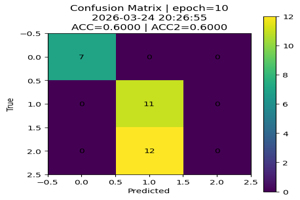

  imagem aberta

  confusion_epoch_11_20260324_202655.png size=25690 bytes
  meta: {'ref': 'confusion_epoch_11_20260324_202655.png', 'kind': 'image', 'mime': 'image/png', 'size': 25690, 'created_ts': 1774384015.8753564, 'name': 'confusion_epoch_11_20260324_202655.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


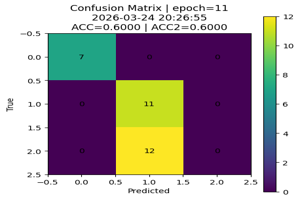

  imagem aberta

  confusion_epoch_12_20260324_202656.png size=25656 bytes
  meta: {'ref': 'confusion_epoch_12_20260324_202656.png', 'kind': 'image', 'mime': 'image/png', 'size': 25656, 'created_ts': 1774384016.2510524, 'name': 'confusion_epoch_12_20260324_202656.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


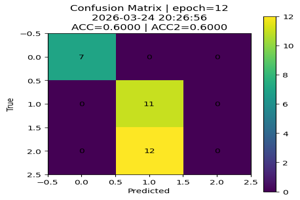

  imagem aberta

  confusion_epoch_13_20260324_202656.png size=25694 bytes
  meta: {'ref': 'confusion_epoch_13_20260324_202656.png', 'kind': 'image', 'mime': 'image/png', 'size': 25694, 'created_ts': 1774384016.6241932, 'name': 'confusion_epoch_13_20260324_202656.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


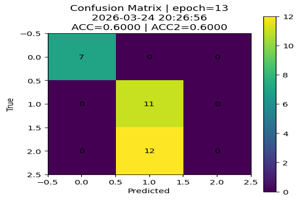

  imagem aberta

  confusion_epoch_14_20260324_202656.png size=25556 bytes
  meta: {'ref': 'confusion_epoch_14_20260324_202656.png', 'kind': 'image', 'mime': 'image/png', 'size': 25556, 'created_ts': 1774384017.0076172, 'name': 'confusion_epoch_14_20260324_202656.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


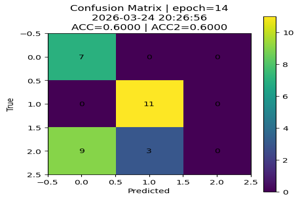

  imagem aberta

  confusion_epoch_15_20260324_202657.png size=25748 bytes
  meta: {'ref': 'confusion_epoch_15_20260324_202657.png', 'kind': 'image', 'mime': 'image/png', 'size': 25748, 'created_ts': 1774384017.426528, 'name': 'confusion_epoch_15_20260324_202657.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


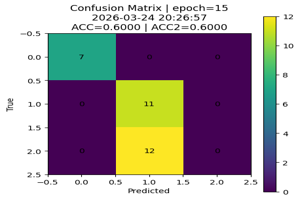

  imagem aberta

  confusion_epoch_16_20260324_202657.png size=25771 bytes
  meta: {'ref': 'confusion_epoch_16_20260324_202657.png', 'kind': 'image', 'mime': 'image/png', 'size': 25771, 'created_ts': 1774384017.9652328, 'name': 'confusion_epoch_16_20260324_202657.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


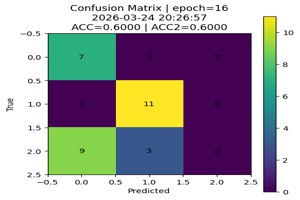

  imagem aberta

  confusion_epoch_17_20260324_202658.png size=25675 bytes
  meta: {'ref': 'confusion_epoch_17_20260324_202658.png', 'kind': 'image', 'mime': 'image/png', 'size': 25675, 'created_ts': 1774384018.476738, 'name': 'confusion_epoch_17_20260324_202658.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


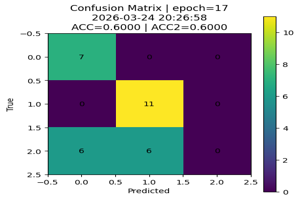

  imagem aberta

  confusion_epoch_18_20260324_202658.png size=26131 bytes
  meta: {'ref': 'confusion_epoch_18_20260324_202658.png', 'kind': 'image', 'mime': 'image/png', 'size': 26131, 'created_ts': 1774384018.9927142, 'name': 'confusion_epoch_18_20260324_202658.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


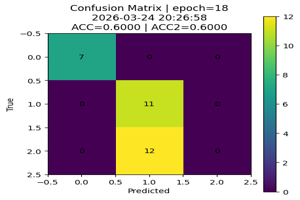

  imagem aberta

  confusion_epoch_19_20260324_202659.png size=25938 bytes
  meta: {'ref': 'confusion_epoch_19_20260324_202659.png', 'kind': 'image', 'mime': 'image/png', 'size': 25938, 'created_ts': 1774384019.5491312, 'name': 'confusion_epoch_19_20260324_202659.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


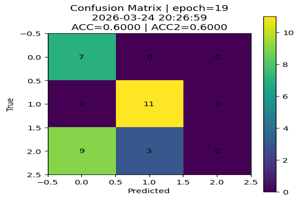

  imagem aberta

  confusion_epoch_1_20260324_202651.png size=25514 bytes
  meta: {'ref': 'confusion_epoch_1_20260324_202651.png', 'kind': 'image', 'mime': 'image/png', 'size': 25514, 'created_ts': 1774384012.1248057, 'name': 'confusion_epoch_1_20260324_202651.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


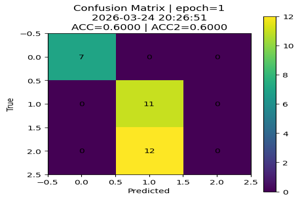

  imagem aberta

  confusion_epoch_20_20260324_202659.png size=26122 bytes
  meta: {'ref': 'confusion_epoch_20_20260324_202659.png', 'kind': 'image', 'mime': 'image/png', 'size': 26122, 'created_ts': 1774384020.045531, 'name': 'confusion_epoch_20_20260324_202659.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


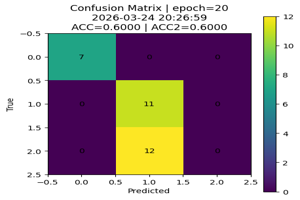

  imagem aberta

  confusion_epoch_21_20260324_202700.png size=25736 bytes
  meta: {'ref': 'confusion_epoch_21_20260324_202700.png', 'kind': 'image', 'mime': 'image/png', 'size': 25736, 'created_ts': 1774384020.4182925, 'name': 'confusion_epoch_21_20260324_202700.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


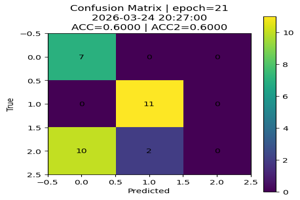

  imagem aberta

  confusion_epoch_22_20260324_202700.png size=25881 bytes
  meta: {'ref': 'confusion_epoch_22_20260324_202700.png', 'kind': 'image', 'mime': 'image/png', 'size': 25881, 'created_ts': 1774384020.7863958, 'name': 'confusion_epoch_22_20260324_202700.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


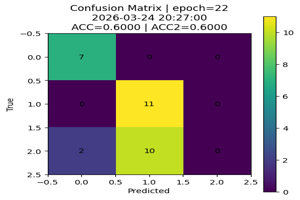

  imagem aberta

  confusion_epoch_23_20260324_202701.png size=25526 bytes
  meta: {'ref': 'confusion_epoch_23_20260324_202701.png', 'kind': 'image', 'mime': 'image/png', 'size': 25526, 'created_ts': 1774384021.176783, 'name': 'confusion_epoch_23_20260324_202701.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


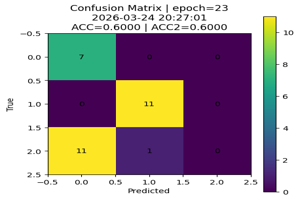

  imagem aberta

  confusion_epoch_24_20260324_202701.png size=25718 bytes
  meta: {'ref': 'confusion_epoch_24_20260324_202701.png', 'kind': 'image', 'mime': 'image/png', 'size': 25718, 'created_ts': 1774384021.545608, 'name': 'confusion_epoch_24_20260324_202701.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


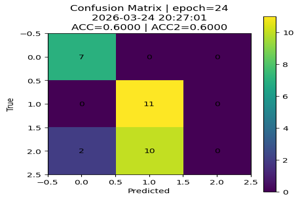

  imagem aberta

  confusion_epoch_25_20260324_202701.png size=25437 bytes
  meta: {'ref': 'confusion_epoch_25_20260324_202701.png', 'kind': 'image', 'mime': 'image/png', 'size': 25437, 'created_ts': 1774384022.3996606, 'name': 'confusion_epoch_25_20260324_202701.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


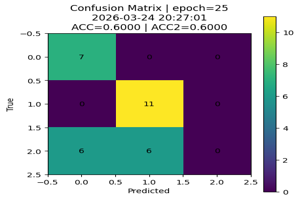

  imagem aberta

  confusion_epoch_26_20260324_202702.png size=25841 bytes
  meta: {'ref': 'confusion_epoch_26_20260324_202702.png', 'kind': 'image', 'mime': 'image/png', 'size': 25841, 'created_ts': 1774384022.7683322, 'name': 'confusion_epoch_26_20260324_202702.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


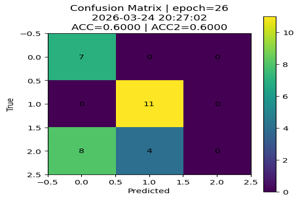

  imagem aberta

  confusion_epoch_27_20260324_202702.png size=25511 bytes
  meta: {'ref': 'confusion_epoch_27_20260324_202702.png', 'kind': 'image', 'mime': 'image/png', 'size': 25511, 'created_ts': 1774384023.1563272, 'name': 'confusion_epoch_27_20260324_202702.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


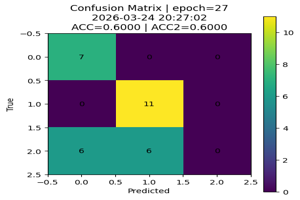

  imagem aberta

  confusion_epoch_28_20260324_202703.png size=25947 bytes
  meta: {'ref': 'confusion_epoch_28_20260324_202703.png', 'kind': 'image', 'mime': 'image/png', 'size': 25947, 'created_ts': 1774384023.5223897, 'name': 'confusion_epoch_28_20260324_202703.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


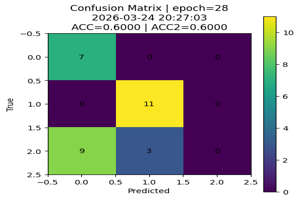

  imagem aberta

  confusion_epoch_29_20260324_202703.png size=25799 bytes
  meta: {'ref': 'confusion_epoch_29_20260324_202703.png', 'kind': 'image', 'mime': 'image/png', 'size': 25799, 'created_ts': 1774384023.8895135, 'name': 'confusion_epoch_29_20260324_202703.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


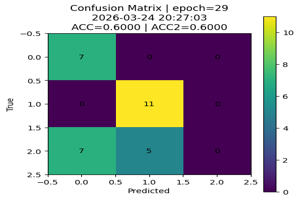

  imagem aberta

  confusion_epoch_2_20260324_202652.png size=26314 bytes
  meta: {'ref': 'confusion_epoch_2_20260324_202652.png', 'kind': 'image', 'mime': 'image/png', 'size': 26314, 'created_ts': 1774384012.49442, 'name': 'confusion_epoch_2_20260324_202652.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


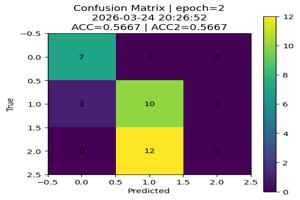

  imagem aberta

  confusion_epoch_30_20260324_202704.png size=25707 bytes
  meta: {'ref': 'confusion_epoch_30_20260324_202704.png', 'kind': 'image', 'mime': 'image/png', 'size': 25707, 'created_ts': 1774384024.277363, 'name': 'confusion_epoch_30_20260324_202704.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


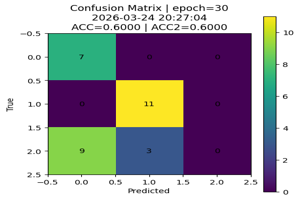

  imagem aberta

  confusion_epoch_3_20260324_202652.png size=26328 bytes
  meta: {'ref': 'confusion_epoch_3_20260324_202652.png', 'kind': 'image', 'mime': 'image/png', 'size': 26328, 'created_ts': 1774384012.8839126, 'name': 'confusion_epoch_3_20260324_202652.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


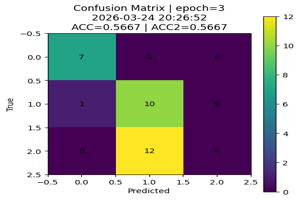

  imagem aberta

  confusion_epoch_4_20260324_202653.png size=25787 bytes
  meta: {'ref': 'confusion_epoch_4_20260324_202653.png', 'kind': 'image', 'mime': 'image/png', 'size': 25787, 'created_ts': 1774384013.2526047, 'name': 'confusion_epoch_4_20260324_202653.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


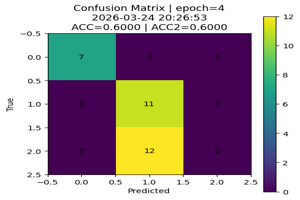

  imagem aberta

  confusion_epoch_5_20260324_202653.png size=26376 bytes
  meta: {'ref': 'confusion_epoch_5_20260324_202653.png', 'kind': 'image', 'mime': 'image/png', 'size': 26376, 'created_ts': 1774384013.6112423, 'name': 'confusion_epoch_5_20260324_202653.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


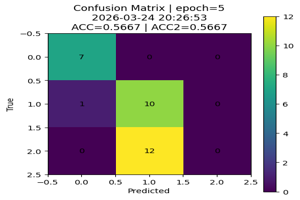

  imagem aberta

  confusion_epoch_6_20260324_202653.png size=25935 bytes
  meta: {'ref': 'confusion_epoch_6_20260324_202653.png', 'kind': 'image', 'mime': 'image/png', 'size': 25935, 'created_ts': 1774384013.9828644, 'name': 'confusion_epoch_6_20260324_202653.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


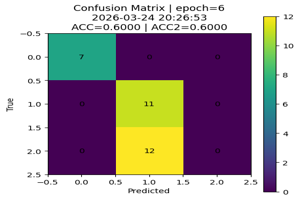

  imagem aberta

  confusion_epoch_7_20260324_202654.png size=25503 bytes
  meta: {'ref': 'confusion_epoch_7_20260324_202654.png', 'kind': 'image', 'mime': 'image/png', 'size': 25503, 'created_ts': 1774384014.3465674, 'name': 'confusion_epoch_7_20260324_202654.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


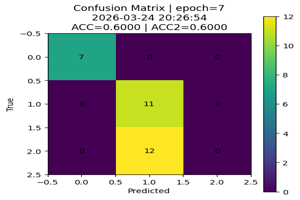

  imagem aberta

  confusion_epoch_8_20260324_202654.png size=25665 bytes
  meta: {'ref': 'confusion_epoch_8_20260324_202654.png', 'kind': 'image', 'mime': 'image/png', 'size': 25665, 'created_ts': 1774384014.7345366, 'name': 'confusion_epoch_8_20260324_202654.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


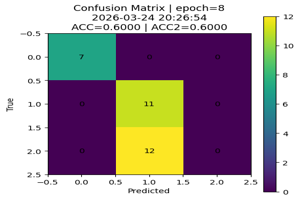

  imagem aberta

  confusion_epoch_9_20260324_202654.png size=25651 bytes
  meta: {'ref': 'confusion_epoch_9_20260324_202654.png', 'kind': 'image', 'mime': 'image/png', 'size': 25651, 'created_ts': 1774384015.1030343, 'name': 'confusion_epoch_9_20260324_202654.png', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}


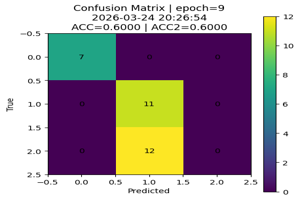

  imagem aberta

  validation_epoch_10_20260324_202655.json size=480 bytes
  meta: {'ref': 'validation_epoch_10_20260324_202655.json', 'kind': 'json', 'mime': 'application/json', 'size': 480, 'created_ts': 1774384015.4917083, 'name': 'validation_epoch_10_20260324_202655.json', 'experiment_id': 'local-d868a691-550a-4ca0-a4b7-df9bf648201f'}
{
  "epoch": 10,
  "created_at": "2026-03-24T20:26:55.305753",
  "loss": 0.7281822164853414,
  "metrics": {
    "ACCURACY": 0.6,
    "ACCURACY_2": 0.6
  },
  "predictions_pairs_ref": "y_true_y_pred_epoch_10.npy",
  "confusion_matrix": [
    [
      7,
      0,
      0
    ],
    [
      0,
      11,
      0
    ],
    [
      0,
      12,
      0
    ]
  ],
  "confusion_image_ref": "confusion_epoch_10_20260324_202655.png"
}

  validation_epoch_11_20260324_202655.json size=480 bytes
  meta: {'ref': 'validation_epoch_11_20260324_202655.json', 'kind': 'json', 'mime': 'application/json', 'size': 480, 'created_ts': 1774384015.882411, 'name': 'validation_ep

In [ ]:
pasta = Path("/content/outputs")

# pega o primeiro arquivo HDF5 gerado
filename = min(pasta.iterdir(), key=lambda f: f.stat().st_mtime)

# mostra a estrutura completa do arquivo
show_h5_structure(filename)

# mostra eventos (logs)
show_events(filename)

# mostra outputs (arrays + blobs)
show_outputs(filename, show_images=True)

-----

# **3. Exemplo MNIST**

Nesta seção é executado um exemplo completo baseado no tutorial oficial para o dataset MNIST disponível no repositório:
🔗 https://github.com/FutureLab-DCC/flautim_tutoriais/tree/main/TUTORIAL_3

Execute a seção 2.1 primeiro:
- Script para preparação e carregamento do dataset MNIST,
- Script para definição do modelo e criação das funções de treinamento/evaluação.

Após concluir essa etapa inicial, você terá duas opções de caminho experimental:
- 2.2. Experimento Centralizado — onde todo o treinamento é feito de forma convencional, agregando os dados em um único nó.
- 2.3. Experimento Federado — onde os dados e o treinamento são distribuídos entre clientes, seguindo o paradigma de aprendizado federado.

Escolha qual tipo de experimento deseja executar (2.2 ou 2.3) de acordo com seus objetivos de análise.

## **3.1. MNISTDataset.py e MNISTModel.py**

*Obs*. Antes de cada experimento, é importante reiniciar o Kernel caso um experimento já tenha executado.

In [ ]:
import IPython
import shutil

shutil.rmtree('/content/configs', ignore_errors=True)

IPython.Application.instance().kernel.do_shutdown(True)
! python3 --version

Python 3.12.9


In [ ]:
import sys
sys.path.append('/usr/local/lib/python3.12/site-packages/')
sys.path.append('/usr/local/lib/python3.12/dist-packages/')
sys.path.append('/usr/local/')
sys.path.append('/usr/lib/python3.12/')
sys.path.append('/usr/local/lib/python3.12/')
#sys.path.append('/content/flautim2')
print (sys.path)

In [ ]:
# ------------------------------------------------------------
# Cria o módulo MNISTDataset, conforme arquivo no tutorial:
# https://github.com/FutureLab-DCC/flautim_tutoriais/tree/main/TUTORIAL_3
# ------------------------------------------------------------
%%writefile /content/MNISTDataset.py
from flautim2.pytorch.Dataset import Dataset
import numpy as np
import pandas as pd
import torch
import copy
from torch.utils.data import DataLoader

class MNISTDataset(Dataset):

    def __init__(self, FM_Normalization, EVAL_Transforms, TRAIN_Transforms, partition, **kwargs):

        name = kwargs.get('name', 'FMNIST')

        super(MNISTDataset, self).__init__(name, **kwargs)

        self.FM_Normalization = FM_Normalization
        self.EVAL_Transforms = EVAL_Transforms
        self.TRAIN_Transforms = TRAIN_Transforms

        self.feature_name = kwargs.get("feature_name", 'image')
        self.split = kwargs.get("split_data", True)

        if self.split:
            partition = partition.train_test_split(test_size=0.2, seed=42)

        self.train_partition = partition["train"]
        self.test_partition = partition["test"]

    def dataloader(self, validation = False):
        tmp = self.validation() if validation else self.train()
        return DataLoader(tmp, batch_size = self.batch_size, num_workers = 1)



    def apply_train_transforms(self, batch):
        """Apply transforms to the partition from FederatedDataset."""
        batch[self.feature_name] = [self.TRAIN_Transforms(img) for img in batch[self.feature_name]]
        return batch


    def  apply_eval_transforms(self, batch):
        """Apply transforms to the partition from FederatedDataset."""
        batch[self.feature_name] = [self.EVAL_Transforms(img) for img in batch[self.feature_name]]
        return batch


    def train(self):

        return self.train_partition.with_transform(self.apply_train_transforms)


    def validation(self):

        return self.test_partition.with_transform(self.apply_eval_transforms)



Writing /content/MNISTDataset.py


In [ ]:
# ------------------------------------------------------------
# Cria o módulo MNISTModel, conforme arquivo no tutorial:
# https://github.com/FutureLab-DCC/flautim_tutoriais/tree/main/TUTORIAL_3
# ------------------------------------------------------------
%%writefile /content/MNISTModel.py

from flautim2.pytorch.Model import Model
import torch
import torch.nn as nn
import torch.nn.functional as F



class MNISTModel(Model):
    def __init__(self, context, num_classes: int, **kwargs) -> None:
        super(MNISTModel, self).__init__(context, name = "MNIST", version = 1, id = 1, **kwargs)
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


Writing /content/MNISTModel.py


## **3.2. MNIST Centralizado**

### 3.2.1. MNISTExperiment.py

Diferentemente do que é apresentado no Tutorial 3 da documentação oficial, para testar a funcionalidade de salvamento de outputs no formato de imagem, esta classe foi modificada para, a cada execução do validation_loop, gerar uma imagem contendo todas as amostras avaliadas no conjunto de validação. Cada elemento da grade apresenta a imagem correspondente, juntamente com a classe predita pelo modelo, a classe real e a época corrente do treinamento.

Ressalta-se que essa estratégia aumenta consideravelmente o tempo de execução do experimento, devido ao custo de renderização e gravação das imagens em disco. Por esse motivo, o número de épocas foi reduzido para duas, de forma a viabilizar os testes sem comprometer excessivamente o tempo total de processamento que pode chegar a 15 ou mais minutos.

In [ ]:
# ------------------------------------------------------------
# Cria o módulo MNISTExperiment
# ------------------------------------------------------------
%%writefile /content/MNISTExperiment.py

from flautim2.pytorch.centralized.Experiment import Experiment
import flautim2 as fl
import flautim2.metrics as flm
import numpy as np
import torch
import time

import io
from datetime import datetime

import matplotlib
matplotlib.use("Agg")  # headless (ex: servidor/pod)
import matplotlib.pyplot as plt

class MNISTExperiment(Experiment):
    def __init__(self, model, dataset, context, **kwargs):
        super(MNISTExperiment, self).__init__(model, dataset, context, **kwargs)

        self.criterion = torch.nn.CrossEntropyLoss()
        self.lr = kwargs.get('lr', 0.001)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        self.epochs = kwargs.get('epochs', 2)
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        torch.multiprocessing.set_sharing_strategy('file_system')

        # Quantas imagens por "montagem" (página) no validation_loop.
        # Se o validation tiver mais do que isso, serão salvas múltiplas páginas.
        self.max_images_per_page = int(kwargs.get("max_images_per_page", 200))
        self.grid_cols = int(kwargs.get("grid_cols", 10))


    def training_loop(self, data_loader):

        self.model.to(self.device)
        self.model.train()

        running_loss = 0.0

        yhat, y_real = [], []

        for batch in data_loader:
            images = batch["image"]
            labels = batch["label"]
            self.optimizer.zero_grad()

            outputs = self.model(images.to(self.device))
            loss = self.criterion(outputs, labels.to(self.device))
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            yhat.append(predicted.detach().cpu())
            y_real.append(labels.detach().cpu())

        accuracy = self.metrics.ACCURACY(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        accuracy_2 = self.metrics.ACCURACY_2(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        avg_trainloss = running_loss / len(data_loader)
        return float(avg_trainloss), {'ACCURACY': accuracy, 'ACCURACY_2': accuracy_2}

    def validation_loop(self, data_loader):

        self.model.to(self.device)
        self.model.eval()

        yhat, y_real = [], []
        images_all = []

        loss = 0.0
        with torch.no_grad():
            for batch in data_loader:
                images = batch["image"].to(self.device)
                labels = batch["label"].to(self.device)
                outputs = self.model(images)
                loss += self.criterion(outputs, labels).item()
                _, predicted = torch.max(outputs.data, 1)
                yhat.append(predicted.detach().cpu())
                y_real.append(labels.detach().cpu())

                # Para a montagem: guarda as imagens já no CPU
                images_all.append(images.detach().cpu())


        y_pred = torch.cat(yhat).numpy()
        y_true = torch.cat(y_real).numpy()
        accuracy = self.metrics.ACCURACY(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        accuracy_2 = self.metrics.ACCURACY_2(torch.cat(yhat).numpy(), torch.cat(y_real).numpy())
        loss = loss / len(data_loader)

        # -------------------------------------------------------------
        # Salvar montagem(s) com TODAS as imagens do validation:
        # - se tiver muitas, salva em múltiplas páginas
        # - cada tile mostra: predita, real e época
        # -------------------------------------------------------------
        try:
            images_np = torch.cat(images_all).numpy()
            epoch = int(getattr(self, "epochs", -1))

            montage_refs = self._save_validation_montages(
                images_np,
                y_pred,
                y_true,
                epoch=epoch,
            )

            fl.log(
                f"Validation montages saved (epoch={epoch})",
                details=f"pages={len(montage_refs)} refs={montage_refs[:5]}{'...' if len(montage_refs)>5 else ''}",
                object="validation",
            )
        except Exception as ex:
            # Não deixa o validation quebrar por causa do plot
            fl.log(
                "Failed to save validation montage(s)",
                details=str(ex),
                object="validation",
            )

        return float(loss), {'ACCURACY': accuracy, 'ACCURACY_2': accuracy_2}

    # ---------------------------------------------------------------------
    # Helpers (montagem de imagens + salvar em HDF5 como output)
    # ---------------------------------------------------------------------
    def _render_prediction_grid(self, images_np, y_pred, y_true, *, epoch: int, page: int, cols: int):
        """
        Renderiza uma figura (PNG) com uma grade de imagens e, no título de cada tile,
        a classe predita, a classe real e a época.

        - images_np: (N, H, W) ou (N, 1, H, W) em numpy
        - y_pred/y_true: arrays (N,)
        """
        imgs = np.asarray(images_np)
        if imgs.ndim == 4 and imgs.shape[1] == 1:
            imgs = imgs[:, 0, :, :]
        if imgs.ndim != 3:
            raise ValueError(f"images_np precisa ter shape (N,H,W) ou (N,1,H,W). Recebido: {imgs.shape}")

        n = int(imgs.shape[0])
        cols = max(1, int(cols))
        rows = int(np.ceil(n / cols))

        # Tamanho ajustado para manter legível
        fig_w = max(8.0, cols * 1.2)
        fig_h = max(6.0, rows * 1.4)

        fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))
        axes = np.atleast_2d(axes)

        for idx in range(rows * cols):
            r, c = divmod(idx, cols)
            ax = axes[r, c]
            ax.axis("off")

            if idx >= n:
                continue

            ax.imshow(imgs[idx], cmap="gray")
            ax.set_title(
                f"p={int(y_pred[idx])} | t={int(y_true[idx])} | e={int(epoch)}",
                fontsize=7,
            )

        now = datetime.now()
        now_str = now.strftime("%Y-%m-%d %H:%M:%S")
        fig.suptitle(f"MNIST Validation | epoch={epoch} | page={page} | {now_str}", fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        buf = io.BytesIO()
        fig.savefig(buf, format="png", bbox_inches="tight")
        plt.close(fig)
        buf.seek(0)
        return buf.read(), now

    def _save_validation_montages(self, images_all, y_pred_all, y_true_all, *, epoch: int):
        """
        Salva uma ou mais montagens (páginas) no HDF5.
        Retorna lista de refs (um por página).
        """
        imgs = np.asarray(images_all)
        y_pred = np.asarray(y_pred_all).astype(np.int64)
        y_true = np.asarray(y_true_all).astype(np.int64)

        n_total = int(imgs.shape[0])
        if n_total == 0:
            return []

        per_page = max(1, int(self.max_images_per_page))
        n_pages = int(np.ceil(n_total / per_page))

        refs = []
        for page in range(n_pages):
            s = page * per_page
            e = min(n_total, (page + 1) * per_page)

            png_bytes, now = self._render_prediction_grid(
                imgs[s:e],
                y_pred[s:e],
                y_true[s:e],
                epoch=epoch,
                page=page,
                cols=self.grid_cols,
            )

            img_name = f"mnist_val_epoch_{epoch}_page_{page}_{now.strftime('%Y%m%d_%H%M%S')}.png"
            img_ref = fl.output_image(
                png_bytes,
                name=img_name,
                meta={
                    "epoch": int(epoch),
                    "page": int(page),
                    "n_pages": int(n_pages),
                    "n_images_in_page": int(e - s),
                    "n_images_total": int(n_total),
                    "created_at": now.isoformat(),
                },
            )
            refs.append(img_ref)

        return refs

Writing /content/MNISTExperiment.py


### 3.2.2. run.py

In [ ]:
import flautim2 as fl
import flautim2.metrics as flm
import MNISTDataset, MNISTModel, MNISTExperiment
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset

from torchvision.transforms import (
    Compose,
    Normalize,
    RandomCrop,
    RandomHorizontalFlip,
    ToTensor,
)


FM_NORMALIZATION = ((0.1307,), (0.3081,))
EVAL_TRANSFORMS = Compose([ToTensor(), Normalize(*FM_NORMALIZATION)])
TRAIN_TRANSFORMS = Compose(
    [
        RandomCrop(28, padding=4),
        RandomHorizontalFlip(),
        ToTensor(),
        Normalize(*FM_NORMALIZATION),
    ]
)

DATASET="ylecun/mnist"

if __name__ == '__main__':

    fl.create_offline_config( "MNIST_Tutorial",  "/content" )

    context = fl.init()

    fl.log(f"Flautim inicializado!!!")

    partition = load_dataset("zalando-datasets/fashion_mnist")

    dataset = MNISTDataset.MNISTDataset(FM_NORMALIZATION, EVAL_TRANSFORMS, TRAIN_TRANSFORMS, partition, split_data=False, batch_size = 32, shuffle = False, num_workers = 0)

    model = MNISTModel.MNISTModel(context, num_classes = 10)

    fl.log(f"Modelo criado!!!")

    experiment = MNISTExperiment.MNISTExperiment(model, dataset,  context)

    fl.log(f"Experimento criado!!!")

    # Exemplo de métrica implementada pelo usuário
    def accuracy_2(y, y_hat):
        y = np.asarray(y)
        y_hat = np.asarray(y_hat)
        return np.mean(y == y_hat)

    # Adiciona a métrica ao módulo de métricas
    flm.Metrics.accuracy_2 = accuracy_2

    fl.log(f"Métrica adicionada!!!")

    experiment.run(metrics = {'ACCURACY': flm.Metrics.accuracy, 'ACCURACY_2': flm.Metrics.accuracy_2})



A configuration file already exists with experiment id 'local-24e30d03-2e20-43f5-9cff-b059528837e3'. Flautim will run using the existing configuration file.


README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
fl.finalize_experiment()

## **3.3. MNIST Federado**

*Obs*. Antes de cada experimento, é importante reiniciar o Kernel caso um experimento já tenha executado.

In [ ]:
import IPython
import shutil

shutil.rmtree('/content/configs', ignore_errors=True)

IPython.Application.instance().kernel.do_shutdown(True)
! python3 --version

In [ ]:
import sys
sys.path.append('/usr/local/lib/python3.12/site-packages/')
sys.path.append('/usr/local/lib/python3.12/dist-packages/')
sys.path.append('/usr/local/')
sys.path.append('/usr/lib/python3.12/')
sys.path.append('/usr/local/lib/python3.12/')
#sys.path.append('/content/flautim2')
print (sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/usr/local/lib/python3.12/site-packages/', '/usr/local/lib/python3.12/dist-packages/', '/usr/local/', '/usr/lib/python3.12/', '/usr/local/lib/python3.12/']


### 3.3.1. MNISTExperiment.py

In [ ]:
# ------------------------------------------------------------
# Cria o módulo MNISTExperiment
# ------------------------------------------------------------
%%writefile /content/MNISTExperiment.py

from flautim2.pytorch.federated.Experiment import Experiment
import flautim2 as fl
import flautim2.metrics as flm
import numpy as np
import torch
import time

class MNISTExperiment(Experiment):
    def __init__(self, model, dataset, context, **kwargs):
        super(MNISTExperiment, self).__init__(model, dataset, context, **kwargs)

        self.criterion = torch.nn.CrossEntropyLoss()
        self.lr = kwargs.get('lr', 0.01)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        self.epochs = kwargs.get('epochs', 30)
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


    def training_loop(self, data_loader):

        self.model.to(self.device)
        self.model.train()

        correct, running_loss = 0.0, 0.0

        for batch in data_loader:
            images = batch["image"]
            labels = batch["label"]
            self.optimizer.zero_grad()

            outputs = self.model(images.to(self.device))
            loss = self.criterion(outputs, labels.to(self.device))
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            correct += (torch.max(outputs, 1)[1].cpu() == labels.cpu()).sum().item()

        accuracy = correct / len(data_loader.dataset)
        avg_trainloss = running_loss / len(data_loader)
        return float(avg_trainloss), {'ACCURACY': accuracy}

    def validation_loop(self, data_loader):

        self.model.to(self.device)
        self.model.eval()

        correct, loss = 0, 0.0
        with torch.no_grad():
            for batch in data_loader:
                images = batch["image"].to(self.device)
                labels = batch["label"].to(self.device)
                outputs = self.model(images)
                loss += self.criterion(outputs, labels).item()
                correct += (torch.max(outputs, 1)[1].cpu() == labels.cpu()).sum().item()

        accuracy = correct / len(data_loader.dataset)
        loss = loss / len(data_loader)

        return float(loss), {'ACCURACY': accuracy}


Overwriting /content/MNISTExperiment.py


### 3.3.2. run.py

In [ ]:
# Resolve problema de criação do arquivo de log do Flower no Google Colab
'''
import os

os.chdir("/content/")
print(os.getcwd())
with open("/content/flower.log", "w") as f:
    f.write("Iniciando")
'''

import logging, os

log_path = "/content/flower.log"
os.makedirs(os.path.dirname(log_path), exist_ok=True)

logger = logging.getLogger("flower")
logger.setLevel(logging.INFO)

fh = logging.FileHandler(log_path, mode="a", encoding="utf-8")
#fh.setFormatter(logging.Formatter("%(asctime)s [%(levelname)s] %(name)s: %(message)s"))
#logger.addHandler(fh)

#logger.info("Log iniciado")

In [ ]:
from flautim2.pytorch.common import run_federated, weighted_average
from flautim2.pytorch import Model, Dataset
from flautim2.pytorch.federated import Experiment
import MNISTDataset, MNISTModel, MNISTExperiment
import flautim2 as fl
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import DirichletPartitioner
from flwr.common import Context, ndarrays_to_parameters
import flwr
import pandas as pd
import numpy as np
from flwr.server import ServerConfig, ServerAppComponents
from datasets import load_dataset

from torchvision.transforms import (
    Compose,
    Normalize,
    RandomCrop,
    RandomHorizontalFlip,
    ToTensor,
)


FM_NORMALIZATION = ((0.1307,), (0.3081,))
EVAL_TRANSFORMS = Compose([ToTensor(), Normalize(*FM_NORMALIZATION)])
TRAIN_TRANSFORMS = Compose(
    [
        RandomCrop(28, padding=4),
        RandomHorizontalFlip(),
        ToTensor(),
        Normalize(*FM_NORMALIZATION),
    ]
)

DATASET = "zalando-datasets/fashion_mnist"
NUM_PARTITIONS = 30

def fit_config(server_round: int):
    """Return training configuration dict for each round.

    Perform two rounds of training with one local epoch, increase to two local
    epochs afterwards.
    """
    config = {
        "server_round": server_round,  # The current round of federated learning
    }
    return config



def generate_server_fn(context, eval_fn, **kwargs):

    def create_server_fn(context_flwr:  Context):

        net = MNISTModel.MNISTModel(context, num_classes = 10, suffix = 0)
        params = ndarrays_to_parameters(net.get_parameters())

        strategy = flwr.server.strategy.FedAvg(
                          initial_parameters=params,
                          evaluate_metrics_aggregation_fn=weighted_average,
                          fraction_fit=0.1,  # 10% clients sampled each round to do fit()
                          fraction_evaluate=0.5,  # 50% clients sample each round to do evaluate()
                          evaluate_fn=eval_fn,
                          on_fit_config_fn = fit_config,
                          on_evaluate_config_fn = fit_config
                          )
        num_rounds = 30
        config = ServerConfig(num_rounds=num_rounds)

        return ServerAppComponents(config=config, strategy=strategy)
    return create_server_fn

def generate_client_fn(context):

    def create_client_fn(context_flwr:  Context):

        global fds

        cid = int(context_flwr.node_config["partition-id"])

        partition = fds.load_partition(cid)

        model = MNISTModel.MNISTModel(context, num_classes = 10, suffix = cid)

        dataset = MNISTDataset.MNISTDataset(FM_NORMALIZATION, EVAL_TRANSFORMS, TRAIN_TRANSFORMS, partition, batch_size = 32, shuffle = False, num_workers = 0)

        return MNISTExperiment.MNISTExperiment(model, dataset,  context).to_client()

    return create_client_fn


def evaluate_fn(context):
    def fn(server_round, parameters, config):
        """This function is executed by the strategy it will instantiate
        a model and replace its parameters with those from the global model.
        The, the model will be evaluate on the test set (recall this is the
        whole MNIST test set)."""

        global FM_NORMALIZATION, EVAL_TRANSFORMS, TRAIN_TRANSFORMS, DATASET
        global fds

        model = MNISTModel.MNISTModel(context, num_classes = 10, suffix = "FL-Global")
        model.set_parameters(parameters)

        partition = fds.load_partition(0)

        dataset = MNISTDataset.MNISTDataset(FM_NORMALIZATION, EVAL_TRANSFORMS, TRAIN_TRANSFORMS, partition, batch_size = 32, shuffle = False, num_workers = 0)
        dataset.test_partition = load_dataset(DATASET)["test"]

        experiment = MNISTExperiment.MNISTExperiment(model, dataset, context)

        config["server_round"] = server_round

        loss, _, return_dic = experiment.evaluate(parameters, config)

        return loss, return_dic

    return fn

partitioner = DirichletPartitioner(
            num_partitions=NUM_PARTITIONS,
            partition_by="label",
            alpha=1.0,
            seed=42,
        )
fds = FederatedDataset(
            dataset=DATASET,
            partitioners={"train": partitioner},
        )

fds.load_partition(0)

if __name__ == '__main__':

    fl.create_offline_config( "MNIST_Tutorial_federado",  "/content" )

    context = fl.init()

    fl.log(f"Flautim inicializado!!!")


    client_fn_callback = generate_client_fn(context)
    evaluate_fn_callback = evaluate_fn(context)
    server_fn_callback = generate_server_fn(context, eval_fn = evaluate_fn_callback)

    fl.log(f"Experimento criado!!!")

    run_federated(client_fn_callback, server_fn_callback, num_clients = NUM_PARTITIONS)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
INFO :      Starting Flower ServerApp, config: num_rounds=30, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provid

A configuration file already exists with experiment id 'local-24e30d03-2e20-43f5-9cff-b059528837e3'. Flautim will run using the existing configuration file.



            Check the following `FEATURE UPDATE` warning message for the preferred
            new mechanism to use this feature in Flower.
        
        ------------------------------------------------------------
        def client_fn(context: Context) -> Client:

		# Your existing client_fn

		# Pass `context` to the constructor
		return FlowerClient(context).to_client()
        ------------------------------------------------------------
        

            Check the following `FEATURE UPDATE` warning message for the preferred
            new mechanism to use this feature in Flower.
        
        ------------------------------------------------------------
        def client_fn(context: Context) -> Client:

		# Your existing client_fn

		# Pass `context` to the constructor
		return FlowerClient(context).to_client()
        ------------------------------------------------------------
        
INFO :      initial parameters (loss, other metrics): 2.3072340206597177, {'ACCURA

In [ ]:
fl.finalize_experiment()

---

# **4. Visualizar arquivo HDF5**

Nesta seção é executado o script que realizada a leitura e visualização do arquivo HDF5 gerado durante a execução do experimento.

In [ ]:
!python3 view_h5.py ./outputs --viewImage

In [ ]:
from IPython.display import HTML, display

with open("/content/outputs/report_h5.html", "r") as f:
    display(HTML(f.read()))